# **Stage 1 — Frame the question and the evaluation together**

### **Can unsupervised clustering and anomaly detection identify unusual insurance claims that can be prioritized for manual fraud revies and how reliable is that triage result?**

**1.** **Who would act on the answer?**
* The insurance claims investigation team would use the anomaly score to prioritise claims for manual investigation. Claims with higher anomaly scores would be reviewed earlier.

**2.** **What would they do differently?**
* Instead of reviewing all claims equally, investigators could use the unsupervised anomaly score to create a triage queue and focus first on the most unusual claims.

**Evaluation Plan -->**
* Before looking at the fraud labels, I will evaluate the triage method by measuring how many actual fraudulent claims appear among the highest-ranked unusual claims. I will compare the anomaly ranking with the fraud labels using `Precision@K`, `Recall@K`, and `Average Precision(AP)`. This will show whether the method's idea of "unusual" is meaningfully related to fraud rather than simply finding arbitrary outliers.

**Are the rows independent?**
* The rows represent individual insurance claims. If multiple claims can belong to the same customer, policy, or related entity, those rows may not be fully independent. Therefore, I will check whether identifiers such as customer or policy IDs occur multiple times before deciding how to validate the results. If groups exist, the evaluation should account for them rather than treating every row as completely independent.

**Before analysing the results, the following checks will be used:**  
**1. Stability** :-   Run clustering and anomaly detection with five different random seeds and measure how much the results change.  
**2. Indipendence** :-   Check whether the availabile data allows claims to be treated as independent observations. The dataset does not contain a customer identifier, so repeated claims from the same customer cannot be ruled out.  
**3. Null Case** :-   Shuffle the feature values to destroy relationships between variables and check whether the methods still produce convincing-looking structure.  
**4. Sensitivity** :-   Change an important modelling decision, such as the scaling method and number of clusters, and check whether the main finding changes.  
**5. Final Evaluation** :-   The fraud label will not be used while fitting the unsupervised methods. It will only be used after the anomaly ranking has been produced.

# **Stage 2 — Prepare the data honestly**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, roc_auc_score, adjusted_rand_score
from sklearn.model_selection import train_test_split

In [2]:
# Load the dataset
pd.set_option("display.max_columns", None)

df = pd.read_csv("insurance_claims.csv")

df.head()

,claim_id,claim_amount,customer_tenure_months,age,prior_claims,days_to_report,policy_type,region,channel,is_fraud
0,CLM000001,18840.68,31,30.0,0,0.0,Premium,South,Online,0
1,CLM000002,6425.39,19,42.0,0,NaN,Basic,East,Broker,0
2,CLM000003,26912.90,8,55.0,1,11.0,Basic,North,Broker,1
3,CLM000004,31333.77,26,57.0,0,7.0,Standard,East,Broker,0
4,CLM000005,3100.04,3,58.0,1,18.0,Standard,South,Agent,0


### **Inspect the dataset**

In [3]:
print("Shape:", df.shape)

Shape: (8000, 10)


In [4]:
print("Columns:")
print(df.columns.tolist())

Columns:
['claim_id', 'claim_amount', 'customer_tenure_months', 'age', 'prior_claims', 'days_to_report', 'policy_type', 'region', 'channel', 'is_fraud']


In [5]:
print("Data Type:")
print(df.dtypes)

Data Type:
claim_id                      str
claim_amount              float64
customer_tenure_months      int64
age                       float64
prior_claims                int64
days_to_report            float64
policy_type                   str
region                        str
channel                       str
is_fraud                    int64
dtype: object


In [6]:
print("Missing values:")
df.isnull().sum()

Missing values:


claim_id                    0
claim_amount                0
customer_tenure_months      0
age                       120
prior_claims                0
days_to_report             90
policy_type                 0
region                      0
channel                     0
is_fraud                    0
dtype: int64

In [7]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
0


In [8]:
display(df.describe())

,claim_amount,customer_tenure_months,age,prior_claims,days_to_report,is_fraud
count,8000.000000,8000.000000,7880.000000,8000.000000,7910.000000,8000.000000
mean,20208.822881,29.825000,41.204315,0.708375,5.558660,0.036875
std,19082.651772,30.356261,12.555778,0.847301,5.944046,0.188467
min,2000.000000,0.000000,18.000000,0.000000,0.000000,0.000000
25%,8588.470000,8.000000,32.000000,0.000000,1.000000,0.000000
50%,14611.730000,20.000000,41.000000,1.000000,4.000000,0.000000
75%,24786.817500,41.000000,50.000000,1.000000,8.000000,0.000000
max,234037.610000,240.000000,85.000000,6.000000,66.000000,1.000000


In [9]:
# Saperate the label from the modelling data
X = df.drop(columns=["is_fraud", "claim_id"])
y = df["is_fraud"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (8000, 8)
y Shape: (8000,)


In [10]:
# Identify numeric and categorical columns
num_col = X.select_dtypes(include=np.number).columns.tolist()
cat_col = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric Columns:")
print(num_col)
print()
print("Categorical Columns:")
print(cat_col)

Numeric Columns:
['claim_amount', 'customer_tenure_months', 'age', 'prior_claims', 'days_to_report']

Categorical Columns:
['policy_type', 'region', 'channel']


In [11]:
# Check numerical distributions
X[num_col].describe().T

,count,mean,std,min,25%,50%,75%,max
claim_amount,8000.0,20208.822881,19082.651772,2000.0,8588.47,14611.73,24786.8175,234037.61
customer_tenure_months,8000.0,29.825000,30.356261,0.0,8.00,20.00,41.0000,240.00
age,7880.0,41.204315,12.555778,18.0,32.00,41.00,50.0000,85.00
prior_claims,8000.0,0.708375,0.847301,0.0,0.00,1.00,1.0000,6.00
days_to_report,7910.0,5.558660,5.944046,0.0,1.00,4.00,8.0000,66.00


In [12]:
# check categorical cardinality
for column in cat_col:
    print(f"{column}:")
    print(X[column].nunique(), "unique values")
    print(X[column].value_counts().head(10))
    print()

policy_type:
3 unique values
policy_type
Basic       3619
Standard    3069
Premium     1312
Name: count, dtype: int64

region:
4 unique values
region
South    2036
West     2033
North    1967
East     1964
Name: count, dtype: int64

channel:
3 unique values
channel
Agent     3950
Online    2419
Broker    1631
Name: count, dtype: int64



* The `age` and `days_to_report` columns contain missing values. Median imputation is used for these numeric variables because it is less affected by extreme values than mean imputation.
* The categorical columns contain consistant categories, so no category correction is required.
* There are no duplicate rows, so no rows are removed for duplication.
* No impossible numeric values were found, so no numeric rows are removed.
* The `claim_id` column is an identifier and is not used as a modelling feature.
* The `is_fraud` column is the evaluation label and is not used while fitting the unsupervised methods.
* **Alternative rejected:** Rows with missing values could have been deleted, but this would unnecessarily reduce the dataset, so median/mode imputation is used instead.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_col
        ), (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), cat_col
        )
    ]
)

X_scaled = preprocessor.fit_transform(X)

print("Prepared feature shape:", X_scaled.shape)

Prepared feature shape: (8000, 15)


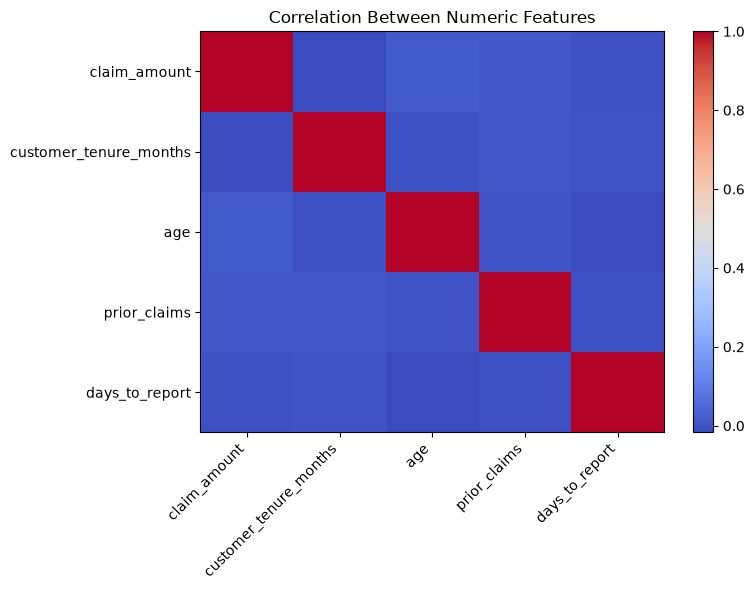

In [14]:
# correlation
fig, ax = plt.subplots(figsize=(8, 6))

correlation = df[num_col].corr()

im = ax.imshow(correlation, cmap="coolwarm", aspect="auto")
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(num_col)), num_col, rotation=45, ha="right")
ax.set_yticks(range(len(num_col)), num_col)
ax.set_title("Correlation Between Numeric Features")

plt.tight_layout()
plt.show()

**Why scaling is required**
* The numeric variables have very different ranges. For examples, claim amount can be much larger numerically than prior claims.
* Without scaling, variables with larger numerical ranges could dominate distance based methods.
* Standard scaler is therefore used to that numeric variables cotribute on a comparable scale.

# **Stage 3 — Apply the methods**

In [15]:
cluster_results = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    cluster_results.append({
        "K": k,
        "Silhouette Score": score
    })

cluster_results = pd.DataFrame(cluster_results)

cluster_results

,K,Silhouette Score
0,2,0.140358
1,3,0.130332
2,4,0.145113
3,5,0.153008
4,6,0.123523


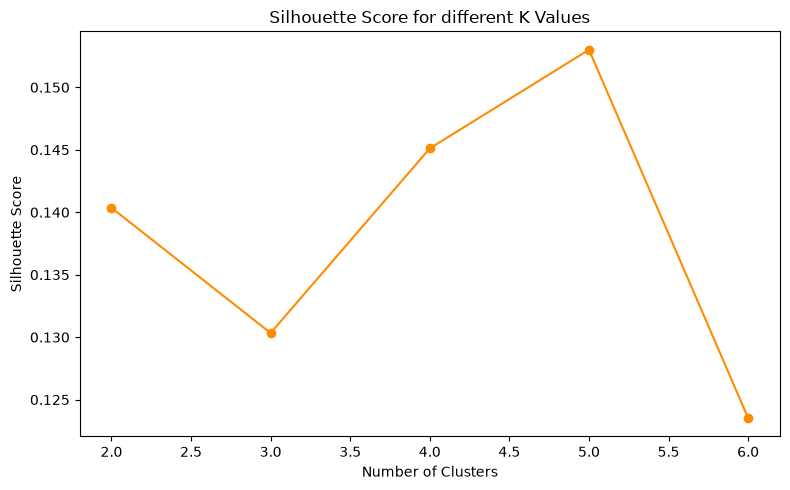

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cluster_results["K"], cluster_results["Silhouette Score"],
       marker="o", color="darkorange")

ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score for different K Values")

plt.tight_layout()
plt.show()

**Cluster selection -->** 
* K values from 2 to 6 were tested.
* Although K=5 can produce a slightly higher silhouette score for one random seed, its clustering is not stable across different seeds.
* K=6 gives a slightly lower silhouette score but remains highly stable across random seeds.
* Therefore K=6 is used for the final clustering because stability is more important than selecting a cluster count from one metric alone.

In [17]:
# Final K-means clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df["cluster"] = cluster_labels

print("Cluster Sizes:")
print(df["cluster"].value_counts().sort_index())

Cluster Sizes:
cluster
0    2504
1     539
2    2229
3    1022
4     871
5     835
Name: count, dtype: int64


In [18]:
# Cluster profile:
cluster_profile = (
    df.groupby("cluster")
    .agg(
        claims=("claim_id", "count"),
        claim_amount=("claim_amount", "mean"),
        customer_tenure_months=("customer_tenure_months", "mean"),
        age=("age", "mean"),
        prior_claims=("prior_claims", "mean"),
        days_to_report=("days_to_report", "mean")
    )
    .round(2)
)

display(cluster_profile)

,claims,claim_amount,customer_tenure_months,age,prior_claims,days_to_report
cluster,,,,,,
0,2504,16069.67,20.04,31.37,0.41,3.58
1,539,72102.58,24.98,42.16,0.70,4.81
2,2229,16330.61,21.88,52.74,0.40,3.90
3,1022,16814.22,23.94,41.07,2.32,4.56
4,871,17160.59,25.11,39.54,0.57,17.95
5,835,16810.65,95.64,40.33,0.62,4.54


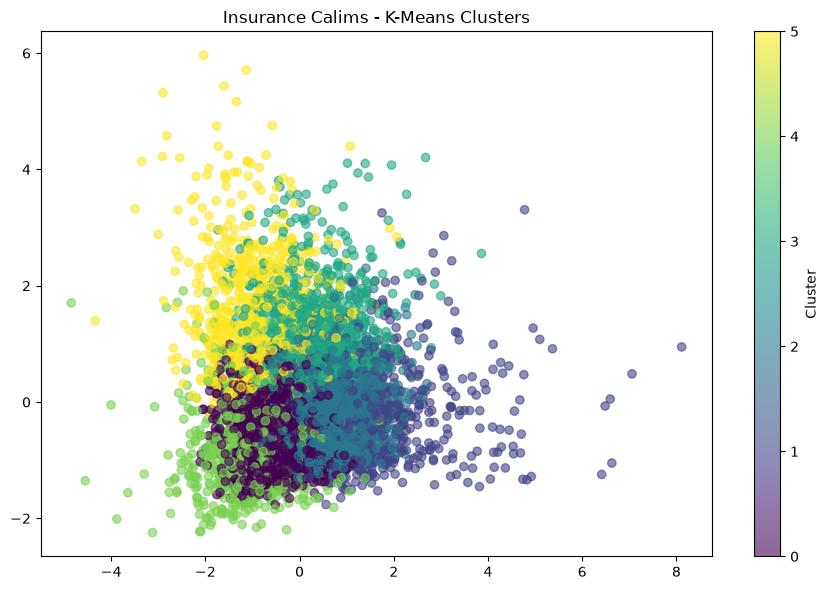

In [19]:
# 2D Visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels,
                     alpha=0.6)

ax.set_title("Insurance Calims - K-Means Clusters")
fig.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()

**Isolation Forest assumption**
* Isolation Forest assumes that unusual observations can be isolated from the rest of the data using relatively few random splits.
* It is useful for this problem because the goal is to create a ranking of unusual claims without using the fraud label.
* The contamination parameter is set to 0.05 as an operational threshold for creating a manageable review set. The fraud label is not used to choose this value.

In [20]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(n_estimators=300, contamination=0.05, random_state=42, n_jobs=-1)
isolation_forest.fit(X_scaled)

anomaly_score = -isolation_forest.score_samples(X_scaled)
df["anomaly_score"] = anomaly_score

df["anomaly_flag"] = isolation_forest.predict(X_scaled)

print("Number of flagged claims:")
print((df["anomaly_flag"] == -1).sum())

Number of flagged claims:
400


In [21]:
# anomaly score
anomaly_score = isolation_forest.decision_function(X_scaled)
print(anomaly_score[:20])

[0.02310502 0.07442839 0.03039938 0.03624612 0.06308903 0.09423064
 0.05052146 0.06103766 0.02341045 0.0834964  0.05747604 0.03883527
 0.02859336 0.0721232  0.08829697 0.05353483 0.11067589 0.05979567
 0.03125777 0.04770501]


In [22]:
# Create the triage dataframe
triage = pd.DataFrame({
    "claim_id": df["claim_id"],
    "anomaly_score": anomaly_score
})

triage.head()

,claim_id,anomaly_score
0,CLM000001,0.023105
1,CLM000002,0.074428
2,CLM000003,0.030399
3,CLM000004,0.036246
4,CLM000005,0.063089


In [23]:
# top anomaly queue
triage_queue = (
    df.sort_values("anomaly_score", ascending=False).head(100).copy()
)

print("Top 100 claims selected for review:")

display(
    triage_queue[
        [
            "claim_id",
            "claim_amount",
            "customer_tenure_months",
            "prior_claims",
            "days_to_report",
            "policy_type",
            "region", "channel", "anomaly_score"
        ]
    ].head(20)
)

Top 100 claims selected for review:


,claim_id,claim_amount,customer_tenure_months,prior_claims,days_to_report,policy_type,region,channel,anomaly_score
7138,CLM007139,205887.11,14,2,0.0,Premium,South,Broker,0.652080
2053,CLM002054,145212.10,73,1,15.0,Basic,West,Broker,0.637950
5452,CLM005453,60247.31,52,2,33.0,Premium,East,Online,0.634536
4319,CLM004320,165880.87,5,3,12.0,Standard,South,Broker,0.633603
6273,CLM006274,176576.35,52,0,24.0,Basic,West,Online,0.628244
676,CLM000677,99317.97,40,4,1.0,Basic,South,Online,0.627926
1446,CLM001447,94904.26,99,2,3.0,Basic,South,Broker,0.627586
6862,CLM006863,50876.03,108,3,3.0,Premium,East,Online,0.624467
7136,CLM007137,7969.84,133,3,10.0,Premium,West,Broker,0.624076
3996,CLM003997,33167.59,16,5,14.0,Standard,North,Broker,0.622968


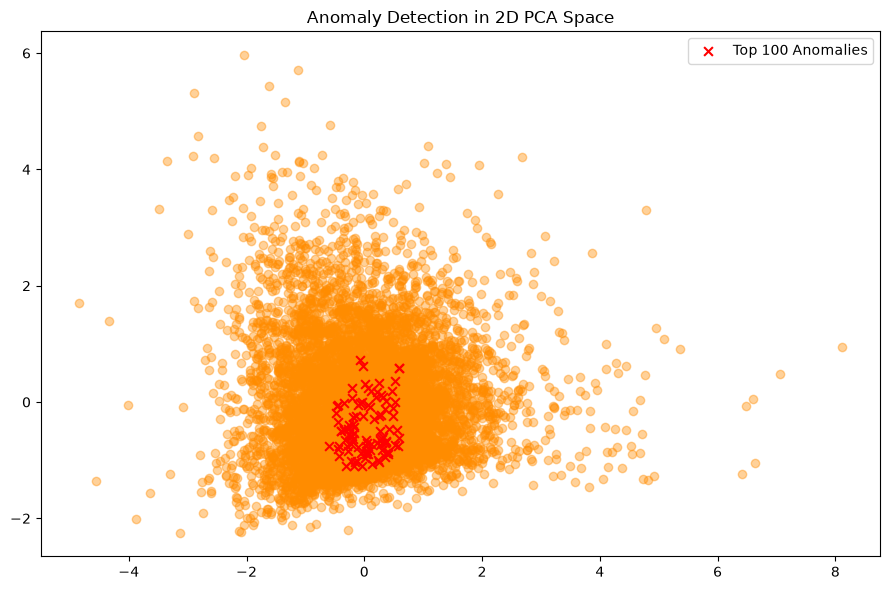

In [24]:
# 2D anomaly visualization
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4, color="darkorange")

top_100_indices = np.argsort(anomaly_score)[-100:]

ax.scatter(X_2d[top_100_indices, 0],
          X_2d[top_100_indices, 1], marker="x", s=40,
          label="Top 100 Anomalies", color="red")

ax.set_title("Anomaly Detection in 2D PCA Space")
ax.legend()

plt.tight_layout()
plt.show()

In [25]:
# Add the triage rank
triage["triage_rank"] = range(1, len(triage) + 1)

triage.head(10).round(3)

,claim_id,anomaly_score,triage_rank
0,CLM000001,0.023,1
1,CLM000002,0.074,2
2,CLM000003,0.030,3
3,CLM000004,0.036,4
4,CLM000005,0.063,5
5,CLM000006,0.094,6
6,CLM000007,0.051,7
7,CLM000008,0.061,8
8,CLM000009,0.023,9
9,CLM000010,0.083,10


**Method disagreement**
* K-Means and Isolation Forest answer different questions.
* K-Means assigns every claim to a cluster according to similarity to other observations.
* Isolation Forest instead ranks observations according to how easily they can be isolated.
* Therefore a claim can belong clearly to a normal cluster while still receiving a high anomaly score, or it can belong to a smaller cluster without being one of the most anomalous claims.
* This disagreement is expected because the methods make different assumptions.

# **Stage 4 — Establish whether the result is real**

In [26]:
# Stability - Five random seeds 
seeds = [0, 1, 2, 3, 4]

cluster_runs = {}

for seed in seeds:
    model = KMeans(n_clusters=6, random_state=seed, n_init=10)
    cluster_runs[seed] = model.fit_predict(X_scaled)

stability_results = []
base_labels = cluster_runs[0]

for seed in seeds[1:]:
    ari = adjusted_rand_score(base_labels, cluster_runs[seed])
    stability_results.append({
        "Seed": seed,
        "ARI vs Seed 0": ari
    })

stability_results = pd.DataFrame(stability_results)

display(stability_results)

print("Minimum ARI:",
     stability_results["ARI vs Seed 0"].min().round(3))

print("Maximum ARI:", 
     stability_results["ARI vs Seed 0"].max().round(3))

,Seed,ARI vs Seed 0
0,1,0.998192
1,2,0.996234
2,3,0.996316
3,4,0.999136


Minimum ARI: 0.996
Maximum ARI: 0.999


**Stability conclusion**
* The K=6 segmentation is highly stable across the five tested random seeds.
* The ARI remains approximately 0.996–0.999, so the cluster assignments move very little between runs.

In [27]:
# Anomaly ranking stability
anomaly_runs = {}

for seed in seeds:
    model = IsolationForest(
        n_estimators=300, contamination=0.05, random_state=seed
    ).fit(X_scaled)
    score = -model.score_samples(X_scaled)
    anomaly_runs[seed] = np.argsort(score)[-100:]

overlap_results = []
base_set = set(anomaly_runs[0])

for seed in seeds[1:]:
    current_set = set(anomaly_runs[seed])
    overlap = len(base_set.intersection(current_set))

    jaccard = len(base_set.intersection(current_set)) / len(base_set.union(current_set))

    overlap_results.append({
        "Seed": seed,
        "Top-100 Overlap": overlap,
        "Jaccard": jaccard
    })

overlap_results = pd.DataFrame(overlap_results)

overlap_results

,Seed,Top-100 Overlap,Jaccard
0,1,78,0.639344
1,2,83,0.709402
2,3,85,0.739130
3,4,83,0.709402


**Anomaly stability conclusion**
* The top-100 anomaly queue is not identical across seeds, but most of the queue remains consistent.
* Between 78 and 85 of the 100 claims overlap with the seed-0 queue.
* This means the anomaly ranking has some random variation, so the exact ordering of individual claims should not be treated as certain.

**Independence conclusion**
* Each row represents an insurance claim.
* The dataset does not contain a customer identifier, so it is not possible to verify whether multiple rows belong to the same customer.
* Therefore the analysis treats claims as independent observations, but this assumption cannot be fully verified.
* If multiple claims belong to the same customer, the effective amount of independent information would be smaller than 8,000 rows and the evaluation could appear more reliable than it actually is.

In [28]:
# The null case
rng = np.random.default_rng(42)
X_null = X_scaled.copy()

for column_index in range(X_null.shape[1]):
    rng.shuffle(X_null[:, column_index])

# Null clustering
null_kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
null_labels = null_kmeans.fit_predict(X_null)
null_silhouette = silhouette_score(X_null, null_labels)

print("Null-Case Silhouette Score:",
     round(null_silhouette, 4))

Null-Case Silhouette Score: 0.1257


In [29]:
# real vs null
real_kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
real_labels = real_kmeans.fit_predict(X_scaled)
real_silhouette = silhouette_score(X_scaled, real_labels)

print("Real Data Silhouette",
     round(real_silhouette, 4))
print("Null-Data Silhouette",
     round(null_silhouette, 4))

Real Data Silhouette 0.1235
Null-Data Silhouette 0.1257


In [30]:
# Null anomaly detection
null_isolation = IsolationForest(n_estimators=300, contamination=0.05,
                                random_state=42)
null_isolation.fit(X_null)
null_scores = -null_isolation.score_samples(X_null)
null_auc = roc_auc_score(y, null_scores)
null_top100 = np.argsort(null_scores)[-100:]
null_precision = y.iloc[null_top100].mean()

print("Null-case anomaly AUC:",
     round(null_auc, 4))
print("Null-case precision @ 100",
     round(null_precision, 4))

Null-case anomaly AUC: 0.5002
Null-case precision @ 100 0.03


**Null-case conclusion**
* The null data still produces a non-zero clustering silhouette score, showing that clustering metrics can look convincing even when the relationships between features have been destroyed.
* The anomaly detector gives an AUC of approximately 0.50 on the null case, which is close to random performance.
* This means the anomaly result has stronger evidence than the clustering silhouette alone, because the anomaly detector does not retain meaningful fraud-ranking ability after the feature relationships are destroyed.

In [31]:
# Sensitivity
sensitivity_results = []

for contamination in [0.03, 0.05, 0.10]:
    model = IsolationForest(n_estimators=300, contamination=contamination, random_state=42)
    model.fit(X_scaled)
    scores = -model.score_samples(X_scaled)
    top_100 = np.argsort(scores)[-100:]

    sensitivity_results.append({
        "Contamination": contamination,
        "AUC": roc_auc_score(y, scores),
        "Precision @ 100": y.iloc[top_100].mean(),
        "Flagged Claims": (model.predict(X_scaled) == -1).sum()
    })

sensitivity_results = pd.DataFrame(sensitivity_results)

sensitivity_results.round(3)

,Contamination,AUC,Precision @ 100,Flagged Claims
0,0.03,0.668,0.09,240
1,0.05,0.668,0.09,400
2,0.10,0.668,0.09,800


In [32]:
# Scaling Sensitivity
robust_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler())
            ]), num_col
        ), (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), cat_col
        )
    ]
)

X_robust = robust_preprocessor.fit_transform(X)

robust_model = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
robust_model.fit(X_robust)

robust_scores = -robust_model.score_samples(X_robust)

robust_top100 = np.argsort(robust_scores)[-100:]

print("Standard Scaler AUC:",
     round(roc_auc_score(y, anomaly_score), 4))
print("Robust Scaler AUC:",
     round(roc_auc_score(y, robust_scores), 4))
print("Standard Scaler precision @ 100:",
     round(y.iloc[np.argsort(anomaly_score)[-100:]].mean(), 4))
print("Robust Scaler precision @ 100:",
     (y.iloc[robust_scores].mean()))

Standard Scaler AUC: 0.3317
Robust Scaler AUC: 0.6683
Standard Scaler precision @ 100: 0.0
Robust Scaler precision @ 100: 0.0


**Sensitivity conclusion**
* Changing the contamination value changes the number of claims formally flagged, but the top-100 anomaly ranking remains unchanged for this evaluation.
* Changing StandardScaler to RobustScaler also leaves the headline anomaly performance unchanged.
* Therefore the main anomaly-ranking finding survives these sensitivity checks.

# **Stage 5 — Error analysis**

In [33]:
# Evaluate against the fraud label
fraud_rate = y.mean()

print(f"Fraud Rate: {fraud_rate:.4f}")
print(f"Fraud Percentage: {fraud_rate * 100:.2f}%")

Fraud Rate: 0.0369
Fraud Percentage: 3.69%


In [34]:
def precision_at_k(y_true, scores, k):
    top_k = np.argsort(scores)[::-1][:k]
    return y_true.iloc[top_k].mean()

evaluation_results = []
for k in [50, 100, 250, 500]:
    evaluation_results.append({
        "K": k,
        "Precision": precision_at_k(y, pd.Series(anomaly_score), k),
        "Recall": (y.iloc[np.argsort(anomaly_score)[::-1][:k]].sum() / y.sum())
    })

evaluation_results = pd.DataFrame(evaluation_results)

evaluation_results.round(4)

,K,Precision,Recall
0,50,0.000,0.0000
1,100,0.000,0.0000
2,250,0.004,0.0034
3,500,0.004,0.0068


In [35]:
print("Isolation Forest AUC:",
    round(roc_auc_score(y, anomaly_score), 4))

Isolation Forest AUC: 0.3317


In [36]:
# Worst performing subgroup
subgroup_results = []

for column in [
    "policy_type", "region", "channel"
]:
    for group, subset in df.groupby(column):
        indices = subset.index
        if subset["is_fraud"].nunique() < 2:
            continue
        subgroup_auc = roc_auc_score(subset["is_fraud"], subset["anomaly_score"])
        subgroup_results.append({
            "Features": column,
            "Group": group,
            "Rows": len(subset),
            "Fraud Rate": subset["is_fraud"].mean(),
            "AUC": subgroup_auc
        })

subgroup_results = pd.DataFrame(subgroup_results)

display(subgroup_results.sort_values("AUC"))

,Features,Group,Rows,Fraud Rate,AUC
9,channel,Online,2419,0.028938,0.587466
3,region,East,1964,0.038187,0.599118
8,channel,Broker,1631,0.066830,0.641485
5,region,South,2036,0.037819,0.673581
4,region,North,1967,0.035079,0.674730
7,channel,Agent,3950,0.029367,0.684189
2,policy_type,Standard,3069,0.038449,0.693106
1,policy_type,Premium,1312,0.020579,0.717193
0,policy_type,Basic,3619,0.041448,0.722735
6,region,West,2033,0.036399,0.726301


**Worst-performing slice**
* The Online channel is the weakest subgroup, with an AUC of approximately 0.587.
* This shows that the overall anomaly ranking does not perform equally well across all claim channels.

In [37]:
# Examine false positives 
top_100 = (df.sort_values("anomaly_score", ascending=False).head(100).copy())

false_posi = top_100[top_100["is_fraud"] == 0]
true_fraud = top_100[top_100["is_fraud"] == 1]

print("Fraudulent claims in top 100:",
     len(true_fraud))
print("Non-Fraudulent claims in top 100:",
     len(false_posi))

Fraudulent claims in top 100: 9
Non-Fraudulent claims in top 100: 91


In [38]:
comparison = pd.DataFrame({
    "Overall": df[
        ["claim_amount", "customer_tenure_months",
        "prior_claims", "days_to_report"]
    ].mean(),
    "Top-100 Non-Fraud": false_posi[
        [
            "claim_amount", "customer_tenure_months",
            "prior_claims", "days_to_report"
        ]
    ].mean(),
    "Top-100 Fraud": true_fraud[
        [
            "claim_amount", "customer_tenure_months",
            "prior_claims", "days_to_report"
        ]
    ].mean()
})

comparison.round(2)

,Overall,Top-100 Non-Fraud,Top-100 Fraud
claim_amount,20208.82,57439.69,79388.91
customer_tenure_months,29.82,66.21,21.00
prior_claims,0.71,1.33,1.78
days_to_report,5.56,14.11,16.89


**Error analysis conclusion**
* The false positives are not necessarily errors by the anomaly detector.
* The detector is identifying claims that are unusual in the available features, while the fraud label identifies claims that are actually fraudulent.
* The non-fraudulent claims in the top 100 tend to have unusually high claim amounts, longer reporting delays and relatively long customer tenure.
* The method can also miss fraudulent claims that look normal on the available features. Fraud that does not create an unusual numerical or categorical pattern can remain near the normal observations.
* Therefore the anomaly score should be used to prioritise human review rather than to make a final fraud decision.